In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [160]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# labeled Supervised Learning : Classification & Regression

지도학습에는 분류와 회귀가 있다

# *** Classification Algorithms ***

# ** Decision Tree **

Root, Leaf, Node 로 이루어짐
스무고개처럼 yes면 left node, no면 right node로 타고 내려감

### child node의 Impurity가 낮아지도록 하기
Information Gain : parents node의 Impurity - child node의 Impurity
이 gain이 크도록 만들기

### Overfitting을 막으려면 tree depth를 제한해야 함
따라서 hyperparameter : max_depth,     min_sample_split,   min_sample_leaf,   max_leaf

## 데이터 읽어오기

In [161]:
penguins = pd.read_csv('https://raw.githubusercontent.com/devdio/flyai_datasets/refs/heads/main/penguins.csv')
print(penguins.shape)
penguins.head()

(344, 7)


,Species,Island,Culmen Length(mm),Culmen Depth(mm),Flipper Length(mm),Body Mass(g),Sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [162]:
penguins['Species'].value_counts()

,count
Species,
Adelie,152
Gentoo,124
Chinstrap,68


### EDA

In [163]:
print(penguins.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Species             344 non-null    object 
 1   Island              344 non-null    object 
 2   Culmen Length(mm)   342 non-null    float64
 3   Culmen Depth(mm)    342 non-null    float64
 4   Flipper Length(mm)  342 non-null    float64
 5   Body Mass(g)        342 non-null    float64
 6   Sex                 334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


위에서 344가 안되는 값은 결측치 (NaN)

In [164]:
penguins.isna().sum()

,0
Species,0
Island,0
Culmen Length(mm),2
Culmen Depth(mm),2
Flipper Length(mm),2
Body Mass(g),2
Sex,10


ㄴ 결측치 갯수

## 데이터 분석

<Axes: xlabel='Culmen Length(mm)', ylabel='Count'>

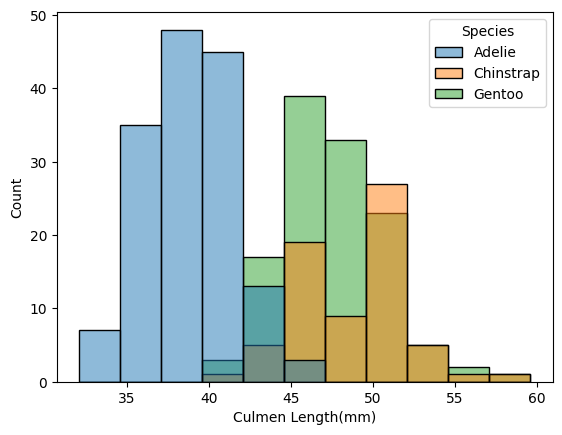

In [165]:
sns.histplot(x='Culmen Length(mm)', data=penguins, hue='Species')

<Axes: xlabel='Culmen Length(mm)', ylabel='Culmen Depth(mm)'>

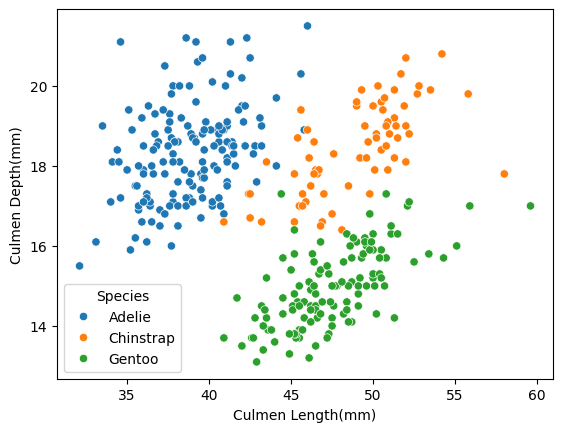

In [166]:
sns.scatterplot(x='Culmen Length(mm)', y='Culmen Depth(mm)', data=penguins, hue='Species')

### histogram으로는 분류하기에 부족한거 같으니까, 두개의 조건을 가지고 비교할수 있는 scatterplot 쓰자

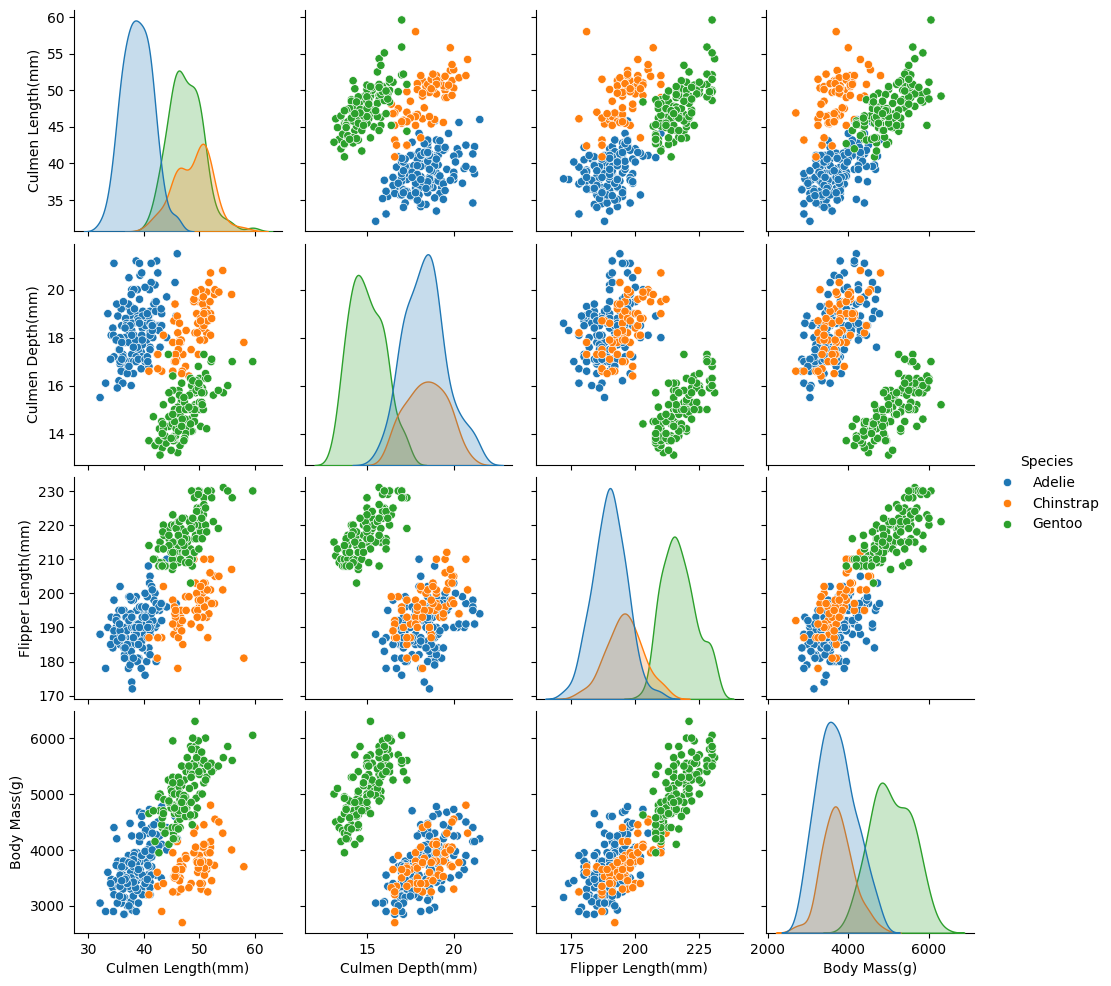

In [167]:
sns.pairplot(penguins, hue='Species')

### 결측치 삭제

In [168]:
penguins = penguins.dropna()

** 보통은 결측치를 지우지 않기 때문에, 데이터 분리를 먼저 함. **

여기서 전체데이터에 drop na를 하지 않고, 결측치가 있는 사항을 따로 찾아 loc로 위치 잡고 np.nan으로 replace해도 됨

* dropna 는 NaN이 하나라도 있으면, 그 데이터 자체를 지움

## * Train, Test 데이터 분리 *



In [169]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(penguins, test_size=0.2, random_state=SEED)    # train 8, test 2
x_train = train.drop('Species', axis=1)
y_train = train['Species']

## * 데이터 전처리 *

### Encoding

In [170]:
from sklearn.preprocessing import OneHotEncoder

x : Island, Sex 인코딩

In [171]:
x_categorical_cols = ['Island', 'Sex']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# x에서 여러개를 한번에 인코딩함
X_ohe = pd.DataFrame(
                    data = ohe.fit_transform(x_train[x_categorical_cols]),
                    columns = ohe.get_feature_names_out(x_categorical_cols),
                    index = x_train.index
                    )
# 인코딩된 X_ohe를 원래 x_train에 갖다 붙임
x_train_e = pd.concat([x_train.drop(x_categorical_cols, axis=1), X_ohe], axis=1)

y : Species 인코딩

In [172]:
y_label_dict = {'Adelie' : 0, 'Chinstrap' : 1, 'Gentoo' : 2}
y_train_e = y_train.map(y_label_dict)
y_train_e = y_train_e.to_numpy()

또는

In [173]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_e = le.fit_transform(y_train)

### Scaling

In [174]:
from sklearn.preprocessing import StandardScaler

scaling은 x만 하면 됨

In [175]:
scaler = StandardScaler()
scaler.fit(x_train_e)
x_train_es = scaler.transform(x_train_e)

## * 모델 학습 *

In [176]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [177]:
clf = DecisionTreeClassifier(random_state=SEED)

param_grid = {
    'max_depth' : [3,4,5],
    'min_samples_split' : [2,5,10],
    'criterion' : ['gini', 'entropy']
        }

grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(x_train_es, y_train_e)

best_model = grid_search.best_estimator_

## * 학습 결과 확인 *

### Plotting Tree

In [178]:
from sklearn.tree import plot_tree

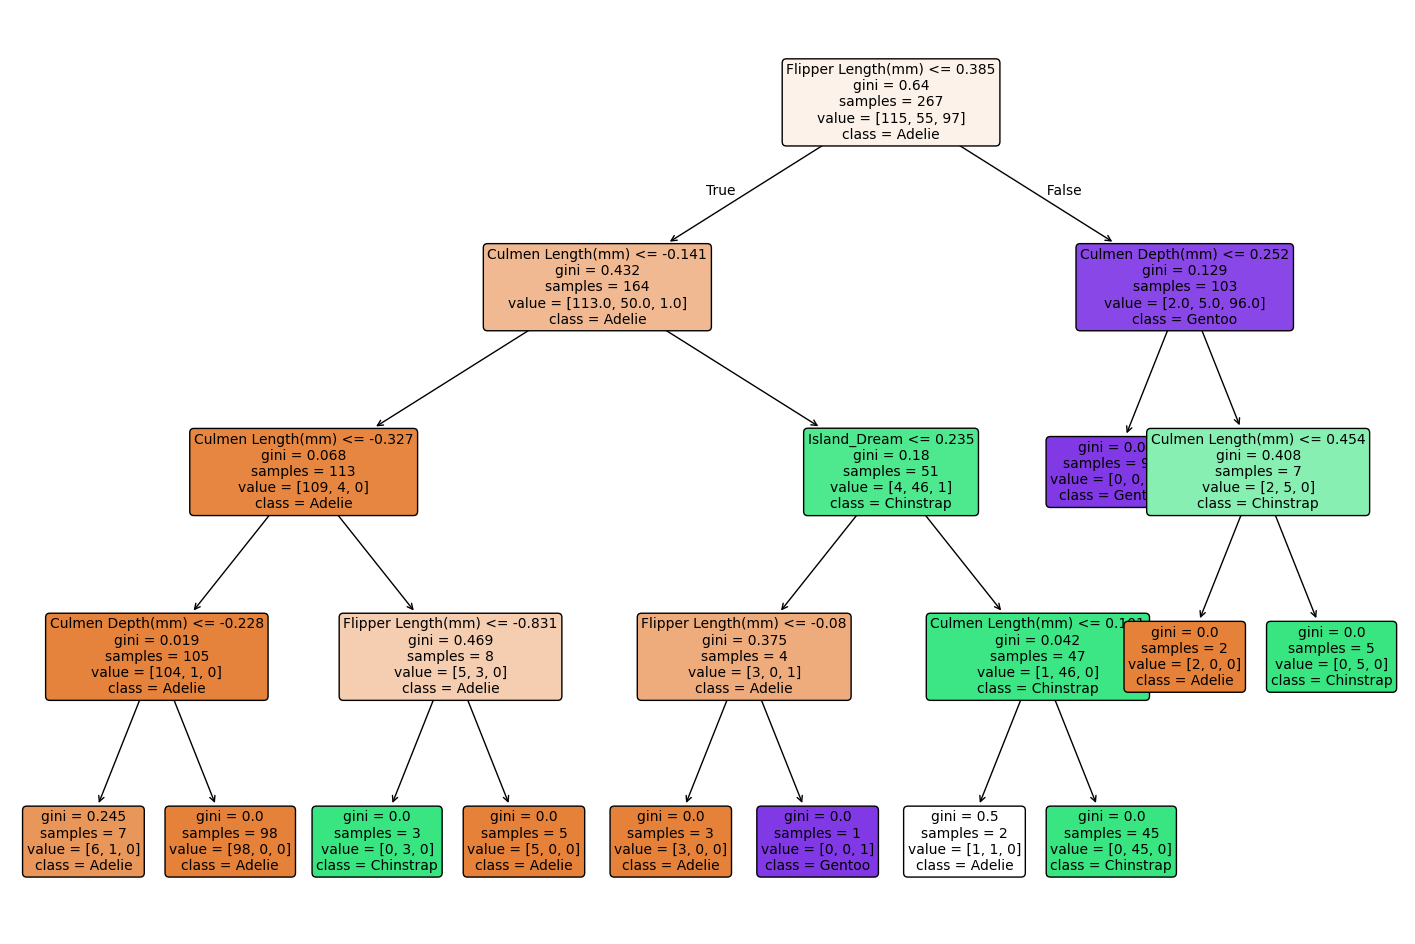

In [179]:
plt.figure(figsize=(18, 12))
plot_tree(
    decision_tree=grid_search.best_estimator_,
    feature_names=x_train_e.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    proportion=False,
    fontsize=10
)
plt.show()

## * Test *

### confusion matrix

다중분류이므로 함수들에 average = 'macro' 넣어주기

In [180]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)    # 맞힌 개수 / 전체 개수
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred, average='macro')     # TP / (TP + FN)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred, average='macro')    # TP / (TP + FP)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred, average='macro')       # (2 * Precision * Recall) / (Precision + Recall)
    print(f"4. F1 Score: {f1:.4f}")

    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

### Test 절차
1. x, y 분리
2. x encoding 및 *scaling*, y encoding - 이때 scaling 방식 통일하기
3. 테스트

x, y 분리

In [181]:
x_test = test.drop('Species', axis=1)
y_test = test['Species']

x, y encoding

test 데이터에서 OneHotEncoder를 다시 fit_transform 하면 안됨 (그건 새로운 ohe를 만드는거임)

그냥 transform 해야함

In [182]:
# x_train에서 사용했던 ohe x_test에도 써먹음
X_ohe_test = pd.DataFrame(
                    data = ohe.transform(x_test[x_categorical_cols]),
                    columns = ohe.get_feature_names_out(x_categorical_cols),
                    index = x_test.index
                    )
x_test_e = pd.concat([x_test.drop(x_categorical_cols, axis=1), X_ohe_test], axis=1)

y_label_dict = {'Adelie' : 0, 'Chinstrap' : 1, 'Gentoo' : 2}
y_test_e = y_test.map(y_label_dict)
y_test_e = y_test_e.to_numpy()

x scaling - scaling 방식 통일

In [183]:
# Use the 'scaler' object that was already fitted on x_train_e in cell 8muoDAoVyVYr
x_test_es = scaler.transform(x_test_e)

테스트

1. Accuracy: 1.0000
2. Recall: 1.0000
3. Precision: 1.0000
4. F1 Score: 1.0000


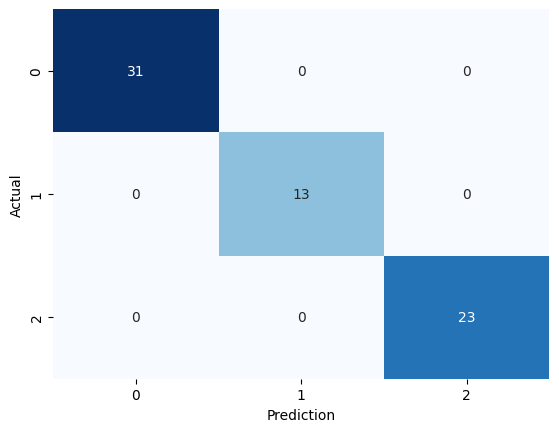

In [184]:
y_predict = best_model.predict(x_test_es)

print_metrics(y_test_e, y_predict)

## * 변수 중요도 *

In [185]:
importances = best_model.feature_importances_
feature_name = x_train_e.columns
print(feature_name)
print(importances)

Index(['Culmen Length(mm)', 'Culmen Depth(mm)', 'Flipper Length(mm)',
       'Body Mass(g)', 'Island_Biscoe', 'Island_Dream', 'Island_Torgersen',
       'Sex_.', 'Sex_FEMALE', 'Sex_MALE'],
      dtype='object')
[0.35554631 0.06333661 0.54711263 0.         0.         0.03400445
 0.         0.         0.         0.        ]


In [186]:
importances_df = pd.DataFrame({'feature': feature_name, 'importance': importances}).sort_values('importance', ascending=False)

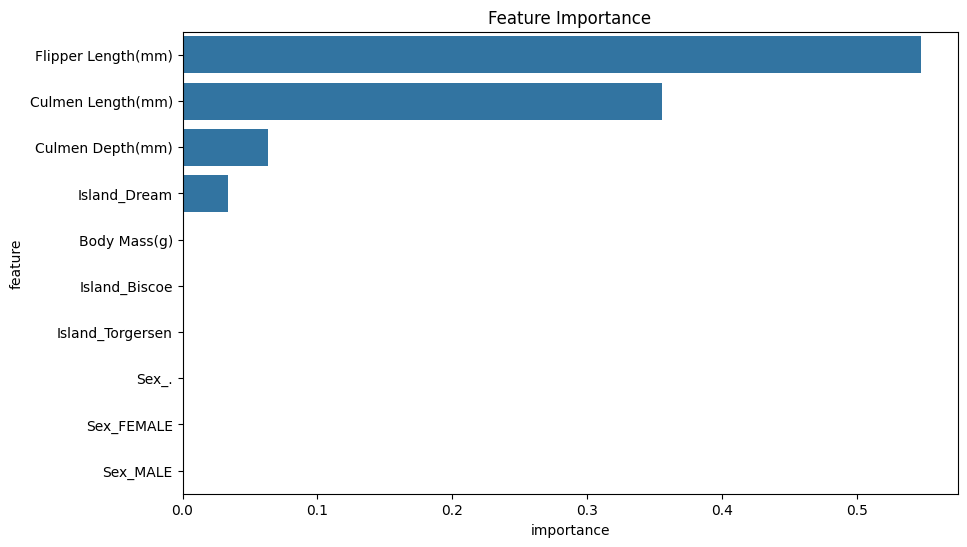

In [187]:
plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importances_df)
plt.title('Feature Importance')
plt.show()